# Kaggle: Predicting a Biological Response (Прогнозирование биологического ответа)

Примечание: Для этой работы данные предварительно уже были **закодированы и нормализованы**.

### Задача: 

Необходимо предсказать биологический ответ молекул (столбец 'Activity') по их химическому составу (столбцы D1-D1776).

Данные представлены в формате CSV.  Каждая строка представляет молекулу. 

Первый столбец Activity содержит экспериментальные данные, описывающие фактический биологический ответ [0, 1]; 
Остальные столбцы D1-D1776 представляют собой молекулярные дескрипторы — это вычисляемые свойства, которые могут фиксировать некоторые характеристики молекулы, например размер, форму или состав элементов.

В качестве метрики будем использовать **F1-score**.

# План выполнения:

Будем решать нашу задачу следующим образом: для начала необходимо обучить две модели: 
- логистическую регрессию
- случайный лес

Затем нужно сделать подбор гиперпараметров с помощью базовых и продвинутых методов оптимизации. 
Будем использовать все четыре метода минимум один раз максимальное количество итераций не будет превышать 50: 
- GridSeachCV, 
- RandomizedSearchCV, 
- Hyperopt, 
- Optuna

In [1]:
import os
import warnings

# Подавление UserWarning в основном и дочерних процессах из-за библиотеки hyperopt!
os.environ["PYTHONWARNINGS"] = "ignore::UserWarning"
warnings.simplefilter("ignore", category=UserWarning)

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import optuna
from hyperopt import hp, fmin, tpe, Trials
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split, cross_val_score
from sklearn.metrics import f1_score

### Загрузка данных

In [3]:
bio_response_df = pd.read_csv('Data/_train_sem09 (1).csv')
display(bio_response_df.head())
display(bio_response_df.info())
display(bio_response_df.isnull().sum())

,Activity,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,D1767,D1768,D1769,D1770,D1771,D1772,D1773,D1774,D1775,D1776
0,1,0.000000,0.497009,0.10,0.0,0.132956,0.678031,0.273166,0.585445,0.743663,...,0,0,0,0,0,0,0,0,0,0
1,1,0.366667,0.606291,0.05,0.0,0.111209,0.803455,0.106105,0.411754,0.836582,...,1,1,1,1,0,1,0,0,1,0
2,1,0.033300,0.480124,0.00,0.0,0.209791,0.610350,0.356453,0.517720,0.679051,...,0,0,0,0,0,0,0,0,0,0
3,1,0.000000,0.538825,0.00,0.5,0.196344,0.724230,0.235606,0.288764,0.805110,...,0,0,0,0,0,0,0,0,0,0
4,0,0.100000,0.517794,0.00,0.0,0.494734,0.781422,0.154361,0.303809,0.812646,...,0,0,0,0,0,0,0,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3751 entries, 0 to 3750
Columns: 1777 entries, Activity to D1776
dtypes: float64(942), int64(835)
memory usage: 50.9 MB


None

Activity    0
D1          0
D2          0
D3          0
D4          0
           ..
D1772       0
D1773       0
D1774       0
D1775       0
D1776       0
Length: 1777, dtype: int64

### Проверим на сбалансированность классов

<Axes: xlabel='Activity', ylabel='count'>

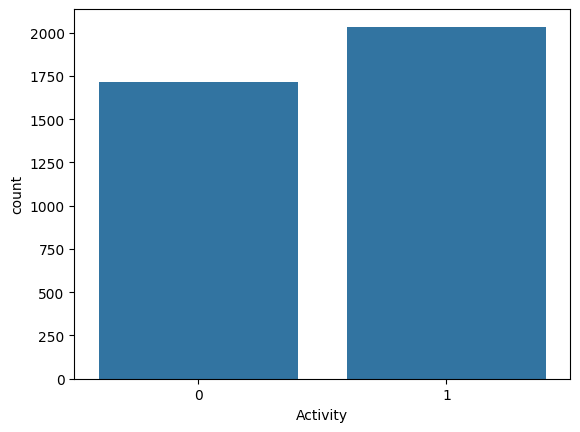

In [4]:
sns.countplot(data=bio_response_df, x='Activity')

# Вывод: 

Классы более или менее сбалансированы, однако стоит все же применить стратификацию к данным.

### Разобьем выборку

In [5]:
X = bio_response_df.drop(['Activity'], axis=1)
y = bio_response_df['Activity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Базовые модели

### Логистическая регрессия

In [6]:
# Создаем модель
lr_model = LogisticRegression(random_state=42, max_iter=1_000)

# Обучаем модель
lr_model.fit(X_train, y_train)

# Предсказываем
y_test_pred = lr_model.predict(X_test)

f1 = f1_score(y_test, y_test_pred)
print(f'Базовая модель {lr_model.__class__.__name__} - F1_score на тестовом наборе: {f1:.2f}')

Базовая модель LogisticRegression - F1_score на тестовом наборе: 0.78


### Случайный лес

In [7]:
# Создаем модель
rf_model = RandomForestClassifier(random_state=42)

# Обучаем модель
rf_model.fit(X_train, y_train)

# Предсказываем
y_test_pred = rf_model.predict(X_test)

f1 = f1_score(y_test, y_test_pred)
print(f'Базовая модель {rf_model.__class__.__name__} - F1_score на тестовом наборе: {f1:.2f}')

Базовая модель RandomForestClassifier - F1_score на тестовом наборе: 0.81


# Вывод:

Базовая модель случайного леса показала чуть лучший результат 0.81, но чуть дольше в выполнении алгоритма.

# Базовые методы оптимизации



### LogisticRegression + GridSearchCV

In [8]:
# Сетка гиперпараметров для логистической регрессии
param_grid = [
    {
        'solver': ['lbfgs'],
        'penalty': ['l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'class_weight': [None, 'balanced']
    },
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'class_weight': [None, 'balanced']
    },
    {
        'solver': ['saga'],
        'penalty': ['l1', 'l2', 'elasticnet'],
        'C': [0.001, 0.01, 0.1, 1, 10],
        'l1_ratio': [0.1, 0.5, 0.9],
        'class_weight': [None, 'balanced']
    }
]

# Модель поиска гиперпараметров
grid_search = GridSearchCV(
    estimator=LogisticRegression(
        random_state=42,
        max_iter=1_000
    ),
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

# Обучаем модель
grid_search.fit(X_train, y_train)

# Предсказание результата
y_test_pred = grid_search.predict(X_test)

# Вывод результатов
display('GridSearchCV + LogisticRegression')
f1 = f1_score(y_test, y_test_pred)
display(f'F1_score на тестовом наборе: {f1:.2f}')
print("Наилучшая модель:\n{}".format(grid_search.best_estimator_))

'GridSearchCV + LogisticRegression'

'F1_score на тестовом наборе: 0.78'

Наилучшая модель:
LogisticRegression(C=0.1, l1_ratio=0.5, max_iter=1000, penalty='elasticnet',
                   random_state=42, solver='saga')


# Вывод:

Использование связки LogisticRegression + GridSearchCV не улучшило нашу базовую метрику F1 (0.78), к тому же подбор занял больше времени чем базовый выариант. Это конечно же не является хорошим результатом! Стоит отказаться от использования в данной задаче этой связки.

### LogisticRegression + RandomizedSearchCV

In [9]:
# Сетка гиперпараметров для логистической регрессии
param_distributions = [
    {
        'solver': ['lbfgs'],
        'penalty': ['l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'class_weight': [None, 'balanced']
    },
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'class_weight': [None, 'balanced']
    },
    {
        'solver': ['saga'],
        'penalty': ['l1', 'l2', 'elasticnet'],
        'C': [0.001, 0.01, 0.1, 1, 10],
        'l1_ratio': [0.1, 0.5, 0.9],
        'class_weight': [None, 'balanced']
    }
]

# Модель поиска гиперпараметров
randomized_search = RandomizedSearchCV(
    estimator=LogisticRegression(
        random_state=42,
        max_iter=1_000
    ),
    param_distributions=param_distributions,
    cv=5,
    n_iter=20,
    scoring='f1',
    n_jobs=-1
)

# Обучаем модель
randomized_search.fit(X_train, y_train)

# Предсказание результата
y_test_pred = randomized_search.predict(X_test)

# Вывод результатов
display('RandomizedSearchCV + LogisticRegression')
f1 = f1_score(y_test, y_test_pred)
display(f'F1_score на тестовом наборе: {f1:.2f}')
print("Наилучшая модель:\n{}".format(randomized_search.best_estimator_))

'RandomizedSearchCV + LogisticRegression'

'F1_score на тестовом наборе: 0.79'

Наилучшая модель:
LogisticRegression(C=0.1, max_iter=1000, random_state=42)


# Вывод:

Использование LogisticRegression + RandomizedSearchCV cмогла немного улучшить нашу базовую метрику до F1 (0.79), также этот алгоритм ожидаемо работает в разы быстрее, что безусловно хорошо! К сожалению это тоже не является хорошим результатом, поскольку наша базовая метрика изменилась, но не намного. Стоит также отказаться от использования в данной задаче этой связки.

### RandomForestClassifier + GridSearchCV

In [10]:
# # Сетка гиперпараметров для случайного леса
# param_grid = {
#     'n_estimators': np.linspace(100, 300, 10, dtype=int),
#     'max_depth': np.linspace(10, 61, 5, dtype=int),
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['sqrt', 'log2', 0.5, 0.7],
#     'class_weight': [None, 'balanced']
# }

# # Модель поиска гиперпараметров
# grid_search = GridSearchCV(
#     estimator=RandomForestClassifier(
#         random_state=42
#     ),
#     param_grid=param_grid,
#     cv=5,
#     scoring='f1',
#     n_jobs=-1
# )

# # Обучаем модель
# grid_search.fit(X_train, y_train)

# # Предсказание результата
# y_test_pred = grid_search.predict(X_test)

# # Вывод результатов
# display('GridSearchCV + RandomForestClassifier')
# f1 = f1_score(y_test, y_test_pred)
# display(f'F1_score на тестовом наборе: {f1:.2f}')
# print("Наилучшая модель:\n{}".format(grid_search.best_estimator_))

# Вывод:

Из-за слишком длительной работы алгоритма (более 4 часов) и далее неизвестно сколько это займет времени, было принято решение не использовать эту связку подбора гиперпараметров. Очевидно, что RandomForestClassifier + GridSearchCV не используема впринципе, поскольку это занимает слишком много времени и не принесет хороших результатов!

### RandomForestClassifier + RandomizedSearchCV

In [11]:
# Сетка гиперпараметров для случайного леса
param_distributions = {
    'n_estimators': np.linspace(100, 300, 10, dtype=int),
    'max_depth': np.linspace(10, 61, 5, dtype=int),
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5, 0.7],
    'class_weight': [None, 'balanced']
}

# Модель поиска гиперпараметров
randomized_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42
    ),
    param_distributions=param_distributions,
    cv=5,
    n_iter=20,
    scoring='f1',
    n_jobs=-1
)

# Обучаем модель
randomized_search.fit(X_train, y_train)

# Предсказание результата
y_test_pred = randomized_search.predict(X_test)

# Вывод результатов
display('RandomizedSearchCV + RandomForestClassifier')
f1 = f1_score(y_test, y_test_pred)
display(f'F1_score на тестовом наборе: {f1:.2f}')
print("Наилучшая модель:\n{}".format(randomized_search.best_estimator_))

# извлечение лучших параметров
best = randomized_search.best_params_

'RandomizedSearchCV + RandomForestClassifier'

'F1_score на тестовом наборе: 0.80'

Наилучшая модель:
RandomForestClassifier(max_depth=61, max_features=0.5, min_samples_split=5,
                       n_estimators=211, random_state=42)


In [12]:
# Создаем модель
rf_model_best = RandomForestClassifier(
    **best,
    random_state=42
)

# Обучаем модель
rf_model_best.fit(X_train, y_train)

# Предсказываем
y_test_pred = rf_model_best.predict(X_test)

f1 = f1_score(y_test, y_test_pred)
print(f'F1_score на тестовом наборе: {f1:.2f}')

F1_score на тестовом наборе: 0.80


# Вывод:

Cвязка RandomForestClassifier + RandomizedSearchCV не смогла улучшить нашу метрику F1 (0.81) и даже немного снизила ее до 0.80. Этот вариант не является рабочим, поскольку нам даже не удалось достичь базовых результатов.

# Продвинутые методы оптимизации

In [13]:
# зафксируем random_state
random_state = 42

### LogisticRegression + Hyperopt + CrossValidation

In [14]:
# Пространство гиперпараметров
space = {
    'C': hp.loguniform('C', -4, 2),  # от ~0.018 до ~7.4
    'solver': hp.choice('solver', ['liblinear', 'lbfgs', 'saga']),
    'penalty': hp.choice('penalty', ['l1', 'l2', 'elasticnet']),
    'class_weight': hp.choice('class_weight', [None, 'balanced']),
    'l1_ratio': hp.choice('l1_ratio', [None, 0.1, 0.5, 0.9])  # используется только при elasticnet
}

def hyperopt_lr(params, cv=5, X=X_train, y=y_train, random_state=random_state):
    # фильтрация совместимых комбинаций
    valid_combinations = {
        'l1': ['liblinear', 'saga'],
        'l2': ['liblinear', 'lbfgs', 'saga'],
        'elasticnet': ['saga']
    }
  
    if params['solver'] not in valid_combinations.get(params['penalty'], []):
        return float('inf')
    # Если penalty не elasticnet, убираем l1_ratio
    if params['penalty'] != 'elasticnet':
        params.pop('l1_ratio', None)

    # Если penalty == elasticnet, l1_ratio должен быть не None
    elif params['l1_ratio'] is None:
        return float('inf')

    # используем эту комбинацию для построения модели
    model = LogisticRegression(
        **params,
        random_state=random_state
    )

    # обучаем модель с помощью кросс-валидации
    score = cross_val_score(model, X, y, cv=cv, scoring="f1", n_jobs=-1).mean()

    # метрику необходимо минимизировать, поэтому ставим знак минус
    return -score

# начинаем подбор гиперпараметров
trials = Trials() # используется для логирования результатов

best = fmin(
    hyperopt_lr, # наша функция
    space=space, # пространство гиперпараметров
    algo=tpe.suggest, # алгоритм оптимизации
    max_evals=20, # максимальное количество итераций
    trials=trials, # логирование результатов
    rstate=np.random.default_rng(random_state),
    return_argmin=False # нужно, для того, чтобы использовать строки, а не индексы
)

100%|██████████| 20/20 [00:32<00:00,  1.63s/trial, best loss: -0.790628907590478]


In [15]:
# Создаем модель
lr_model_best = LogisticRegression(
    **best,
    random_state=random_state
)

# Обучаем модель
lr_model_best.fit(X_train, y_train)

# Предсказываем
y_test_pred = lr_model_best.predict(X_test)

display('Hyperopt + LogisticRegression + CrossValidation')
print(f"Наилучшие значения гиперпараметров {best}")
f1 = f1_score(y_test, y_test_pred)
print(f'F1_score на тестовом наборе: {f1:.2f}')

'Hyperopt + LogisticRegression + CrossValidation'

Наилучшие значения гиперпараметров {'C': 0.24907224648014947, 'class_weight': None, 'l1_ratio': 0.1, 'penalty': 'l1', 'solver': 'saga'}
F1_score на тестовом наборе: 0.78


# Вывод:

Связка Hyperopt + CrossValidation в случае с логистической регрессией не смогла повысить метрику f1, результаты остались базовыми. Несмотря на быстрое время работы алгоритма hyperopt, этот вариант стоит оставить, поскольку качество метрики не улучшилось.

### LogisticRegression + Optuna + CrossValidation

In [16]:
def optuna_lr(trial):
    # выбор гиперпараметров
    solver = trial.suggest_categorical('solver', ['liblinear', 'lbfgs', 'saga'])
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet'])
    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])
    C = trial.suggest_float('C', 0.018, 7.4, log=True)
    l1_ratio = trial.suggest_categorical('l1_ratio', [None, 0.1, 0.5, 0.9])

    # проверка допустимости комбинации solver + penalty
    valid_combinations = {
        'l1': ['liblinear', 'saga'],
        'l2': ['liblinear', 'lbfgs', 'saga'],
        'elasticnet': ['saga']
    }

    if solver not in valid_combinations.get(penalty, []):
        raise optuna.exceptions.TrialPruned()  # прерываем неподходящую попытку

    if penalty == 'elasticnet' and l1_ratio is None:
        raise optuna.exceptions.TrialPruned()

    # параметры модели
    params = {
        'solver': solver,
        'penalty': penalty,
        'class_weight': class_weight,
        'C': C,
        'max_iter': 1_000
    }

    if penalty == 'elasticnet':
        params['l1_ratio'] = l1_ratio

    model = LogisticRegression(
        **params,
        random_state=random_state
    )

    # F1-кросс-валидация
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1).mean()

    return score  # Optuna будет максимизировать F1

# запуск оптимизации
study = optuna.create_study(direction='maximize')
study.optimize(optuna_lr, n_trials=20, show_progress_bar=True)

# извлечение лучших параметров
best = study.best_params

[I 2025-07-26 12:35:14,877] A new study created in memory with name: no-name-9e38d27f-bd22-4692-9549-904f36f05152


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-07-26 12:35:14,902] Trial 0 pruned. 
[I 2025-07-26 12:35:18,305] Trial 1 finished with value: 0.7813506545224438 and parameters: {'solver': 'lbfgs', 'penalty': 'l2', 'class_weight': None, 'C': 0.19249281619761185, 'l1_ratio': 0.5}. Best is trial 1 with value: 0.7813506545224438.
[I 2025-07-26 12:35:18,803] Trial 2 finished with value: 0.7812468692517662 and parameters: {'solver': 'liblinear', 'penalty': 'l1', 'class_weight': 'balanced', 'C': 0.1379243100054918, 'l1_ratio': 0.9}. Best is trial 1 with value: 0.7813506545224438.
[I 2025-07-26 12:35:59,812] Trial 3 finished with value: 0.7622622016245015 and parameters: {'solver': 'saga', 'penalty': 'l2', 'class_weight': 'balanced', 'C': 5.3517803018674845, 'l1_ratio': 0.9}. Best is trial 1 with value: 0.7813506545224438.
[I 2025-07-26 12:36:00,393] Trial 4 finished with value: 0.7814694646699688 and parameters: {'solver': 'liblinear', 'penalty': 'l2', 'class_weight': 'balanced', 'C': 0.04123270262014697, 'l1_ratio': 0.5}. Best is 

In [17]:
# Создаем модель
lr_model_best = LogisticRegression(
    **best,
    random_state=random_state
)

# Обучаем модель
lr_model_best.fit(X_train, y_train)

# Предсказываем
y_test_pred = lr_model_best.predict(X_test)

display('Optuna + LogisticRegression + CrossValidation')
print(f"Наилучшие значения гиперпараметров {best}")
f1 = f1_score(y_test, y_test_pred)
print(f'F1_score на тестовом наборе: {f1:.2f}')

'Optuna + LogisticRegression + CrossValidation'

Наилучшие значения гиперпараметров {'solver': 'liblinear', 'penalty': 'l2', 'class_weight': None, 'C': 0.035594840229695814, 'l1_ratio': None}
F1_score на тестовом наборе: 0.79


# Вывод:

Связка Optuna + CrossValidation в случае с логистической регрессией смогла немного повысить метрику f1 до 0.79, время затраченное на оптимизацию оказалось чуть выше, чем с hyperopt. Как бы мы не старались подобрать оптимальные гиперпараметры для модели логистической регрессии сама модель для этой задаче не способна выдать более высокий результат. Поэтому не стоит использовать логистическую регрессию в данной задаче. Более перспективной моделью машинного обучения в данной задаче возможно является случайный лес.

### RandomForestClassifier + Hyperopt + CrossValidation

In [36]:
# зададим пространство поиска гиперпараметров
space = {
    'n_estimators': hp.quniform('n_estimators', 100, 500, 50),
    'max_depth': hp.quniform('max_depth', 10, 61, 2),
    'min_samples_leaf': hp.quniform('min_samples_leaf', 1, 10, 1),
    'min_samples_split': hp.quniform('min_samples_split', 2, 10, 1),
    'max_features': hp.choice('max_features', ['sqrt', 'log2', 0.5, 0.7]),
    'bootstrap': hp.choice('bootstrap', [True, False]),
    'class_weight': hp.choice('class_weight', [None, 'balanced'])
}

def hyperopt_rf(params, cv=5, X=X_train, y=y_train, random_state=random_state):
    # Пришлось явно приводит типы, т.к. ниже появлялась ошибка, что вместо True/False (bootstrap)
    # в best получаем 1/0
    bootstrap_choices = [True, False]
    params['bootstrap'] = bootstrap_choices[params['bootstrap']]
    
    # функция получает комбинацию гиперпараметров в "params"
    params = {
        'n_estimators': int(params['n_estimators']),
        'max_depth': int(params['max_depth']),
        'min_samples_leaf': int(params['min_samples_leaf']),
        'min_samples_split': int(params['min_samples_split']),
        'max_features': params['max_features'],
        'bootstrap': params['bootstrap'],
        'class_weight': params['class_weight']
    }
  
    # используем эту комбинацию для построения модели
    model = RandomForestClassifier(
        **params, 
        random_state=random_state
    )

    # обучаем модель с кросс валидацией
    score = cross_val_score(model, X, y, cv=cv, scoring="f1", n_jobs=-1).mean()

    # метрику необходимо минимизировать, поэтому ставим знак минус
    return -score

# начинаем подбор гиперпараметров
trials = Trials() # используется для логирования результатов

best = fmin(
    hyperopt_rf, # наша функция
    space=space, # пространство гиперпараметров
    algo=tpe.suggest, # алгоритм оптимизации, установлен по умолчанию, задавать необязательно
    max_evals=20, # максимальное количество итераций
    trials=trials, # логирование результатов
    rstate=np.random.default_rng(random_state),
    return_argmin=False
)

100%|██████████| 20/20 [16:26<00:00, 49.31s/trial, best loss: -0.8205336015728932]


# Вывод:

Связка RandomForestClassifier + Hyperopt + CrossValidation не смогла существенно повысить метрику f1 выше 0.81, время затраченное на оптимизацию оказалось приемлемым. Однако стоит учитывать, что hyperopt является более старым вариантом оптимизатора, поэтому стоит обратить внимание на Optuna, который также работает и нейронными сетями.

### RandomForestClassifier + Optuna + CrossValidation

In [53]:
def optuna_rf(trial):
  # функция получает комбинацию гиперпараметров в "params"
  params = {
      'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=30),
      'max_depth': trial.suggest_int('max_depth', 10, 61, step=2),
      'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10, step=1),
      'min_samples_split': trial.suggest_int('min_samples_split', 2, 10, step=1),
      'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.7]),
      'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
      'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])
  }

  # создаем модель
  model = RandomForestClassifier(
    **params,
    random_state=random_state
  )
  
  # обучаем модель с кросс валидацией
  score = cross_val_score(model, X, y, cv=5, scoring="f1", n_jobs=-1).mean()

  return score

# cоздаем объект исследования
# можем напрямую указать, что нам необходимо максимизировать метрику direction="maximize"
study = optuna.create_study(study_name="RandomForestClassifier", direction="maximize")

# ищем лучшую комбинацию гиперпараметров n_trials раз
study.optimize(optuna_rf, n_trials=20)

[I 2025-07-26 23:07:24,329] A new study created in memory with name: RandomForestClassifier
[I 2025-07-26 23:07:36,872] Trial 0 finished with value: 0.8036652796002602 and parameters: {'n_estimators': 400, 'max_depth': 26, 'min_samples_leaf': 8, 'min_samples_split': 4, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': None}. Best is trial 0 with value: 0.8036652796002602.
[I 2025-07-26 23:08:48,420] Trial 1 finished with value: 0.8127967752786972 and parameters: {'n_estimators': 160, 'max_depth': 12, 'min_samples_leaf': 4, 'min_samples_split': 6, 'max_features': 0.7, 'bootstrap': True, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.8127967752786972.
[I 2025-07-26 23:08:55,142] Trial 2 finished with value: 0.7876268631446005 and parameters: {'n_estimators': 370, 'max_depth': 44, 'min_samples_leaf': 10, 'min_samples_split': 7, 'max_features': 'log2', 'bootstrap': False, 'class_weight': None}. Best is trial 1 with value: 0.8127967752786972.
[I 2025-07-26 23:11:33,275]

In [ ]:
# рассчитаем точность для тестовой выборки
rf_model_best = RandomForestClassifier(
    **study.best_params,
    random_state=random_state
)

rf_model_best.fit(X_train, y_train)
y_test_pred = rf_model_best.predict(X_test)

display('Optuna + RandomForestClassifier + CrossValidation')
print(f"Наилучшие значения гиперпараметров {study.best_params}")
f1 = f1_score(y_test, y_test_pred)
print(f'f1_score на тестовом наборе: {f1:.2f}')

'Optuna + RandomForestClassifier + CrossValidation'

Наилучшие значения гиперпараметров {'bootstrap': False, 'class_weight': None, 'max_depth': 34.0, 'max_features': 0.7, 'min_samples_leaf': 2.0, 'min_samples_split': 2.0, 'n_estimators': 450.0}
f1_score на тестовом наборе: 0.81


Попробуем улучшить результат. Для начала обратим внимание на параметры, какие из них наиболее важны с точки зрения влияния на результат.

In [55]:
optuna.visualization.plot_param_importances(study, target_name="f1_score")

In [57]:
def optuna_rf(trial):
  # функция получает комбинацию гиперпараметров в "params"
  params = {
    'n_estimators': 450,  # фиксируем
    'max_depth': 34,  # фиксируем
    'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 10),  # важен
    'min_samples_split': 2,  # фиксируем
    'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log', 0.2, 0.7]),  # самый важный
    'bootstrap': False,  # фиксируем
    'class_weight': None  # фиксируем
  }

  # создаем модель
  model = RandomForestClassifier(
    **params,
    random_state=random_state
  )
  
  # обучаем модель с кросс валидацией
  score = cross_val_score(model, X, y, cv=5, scoring="f1", n_jobs=-1).mean()

  return score

# cоздаем объект исследования
# можем напрямую указать, что нам необходимо максимизировать метрику direction="maximize"
study = optuna.create_study(study_name="RandomForestClassifier", direction="maximize")

# ищем лучшую комбинацию гиперпараметров n_trials раз
study.optimize(optuna_rf, n_trials=10)

[I 2025-07-27 00:01:50,723] A new study created in memory with name: RandomForestClassifier
[I 2025-07-27 00:02:07,993] Trial 0 finished with value: 0.8137762689864863 and parameters: {'min_samples_leaf': 8, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8137762689864863.
[I 2025-07-27 00:02:27,141] Trial 1 finished with value: 0.8161754540452119 and parameters: {'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.8161754540452119.
[I 2025-07-27 00:04:05,141] Trial 2 finished with value: 0.8221017196315966 and parameters: {'min_samples_leaf': 5, 'max_features': 0.2}. Best is trial 2 with value: 0.8221017196315966.
[I 2025-07-27 00:04:22,947] Trial 3 finished with value: 0.8141866208834223 and parameters: {'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.8221017196315966.
[I 2025-07-27 00:06:19,813] Trial 4 finished with value: 0.8167041618558871 and parameters: {'min_samples_leaf': 2, 'max_features': 0.2}. Best is trial 2 w

In [60]:
# рассчитаем точность для тестовой выборки
rf_model_best = RandomForestClassifier(
    n_estimators = 450,
    max_depth = 34,
    min_samples_split = 2,
    bootstrap = True,
    class_weight = None,
    **study.best_params,
    random_state=random_state
)

rf_model_best.fit(X_train, y_train)

y_test_pred = rf_model_best.predict(X_test)

display('Optuna + RandomForestClassifier + CrossValidation')
print(f"Наилучшие значения гиперпараметров {study.best_params}")
f1 = f1_score(y_test, y_test_pred)
print(f'f1_score на тестовом наборе: {f1:.2f}')

'Optuna + RandomForestClassifier + CrossValidation'

Наилучшие значения гиперпараметров {'bootstrap': False, 'class_weight': None, 'max_depth': 34.0, 'max_features': 0.7, 'min_samples_leaf': 2.0, 'min_samples_split': 2.0, 'n_estimators': 450.0}
f1_score на тестовом наборе: 0.81


# Итоговый вывод:

Используя методы оптимизации с **логистической регрессией** все же немного удалось повысить метрику до f1 - 0.79, но даже проведя более тонкую настройку врядли удастся добится более высоких результатов с **логистической регрессией**. Судя по всему алгоритм машинного обучения - **логистическая регрессия** плохо подходит для данной задачи.

**Случайный лес** выдал на базовых настройках результат выше - f1 в 0.81. Продвинутые методы оптимизации: **hyperopt** и **optuna**, которые использовались в этой задаче прибавили к метрике f1, хотя и не всегда работали быстро. Hyperopt в итоге смог подобрать гиперпараметры, которые дали результат f1 в 0.81. Оptuna смог оптимизировать случайный лес с метрикой f1 в 0.81.

Учитывая, что **Optuna** является более современным и гибким решением, стоит использовать его в этой задаче. Для достижения более высоких показателей предсказаний по видимому стоит использовать другие механизмы машинного обучения, например нейронные сети, которые работают в разы быстрее на больших данных, но требуют определенную архитектуру.